# 05 · CausalForest DML

Estimate heterogeneous treatment effects using Double Machine Learning with a CausalForest final stage. This flexibly controls for observables and allows us to ask: does the effect of cabin expansion differ by brand tier or ship size?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

panel  = pd.read_parquet(DATA_DIR / "ship_month_panel.parquet")
events = pd.read_csv(DATA_DIR / "category_change_events.csv", parse_dates=["event_month"])

print(f"Panel: {panel.shape}  |  Events: {len(events)}")

Panel: (38400, 15)  |  Events: 144


In [2]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder

# DML works cross-sectionally on the residualized data.
# We first partial out ship-level averages (a simple within-ship demeaning)
# to approximate what panel FE does, then run DML on residuals.

# --- Demean within ship ---
panel["cat_dm"]  = panel["cabin_category_count"] - panel.groupby("ship_id")["cabin_category_count"].transform("mean")
panel["lrpb_dm"] = panel["log_revenue_per_berth"] - panel.groupby("ship_id")["log_revenue_per_berth"].transform("mean")

# Keep only treated ships post-demeaning for the heterogeneity analysis
# (where we actually observe variation in treatment)
treated_ids = events["ship_id"].tolist()
p_treated = panel[panel["ship_id"].isin(treated_ids)].copy()

# Encode categoricals
le_tier   = LabelEncoder().fit(panel["brand_tier"])
le_region = LabelEncoder().fit(panel["sailing_region"])
p_treated = p_treated.copy()
p_treated["tier_enc"]   = le_tier.transform(p_treated["brand_tier"])
p_treated["region_enc"] = le_region.transform(p_treated["sailing_region"])

X = p_treated[["log_revenue_per_berth", "berth_capacity", "tier_enc", "region_enc"]].values  # confounders
T = p_treated["cat_dm"].values     # demeaned treatment
Y = p_treated["lrpb_dm"].values    # demeaned outcome

print(f"DML input: {X.shape[0]:,} rows, {X.shape[1]} confounders")

DML input: 6,912 rows, 4 confounders


In [3]:
# Fit CausalForestDML
est = CausalForestDML(
    model_t=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    n_estimators=200,
    random_state=42,
    cv=3,
)
est.fit(Y, T, X=X)
print("CausalForestDML fitted.")

CausalForestDML fitted.


In [4]:
# ATE estimate
import numpy as _np
_effects = est.effect(X)
_lb, _ub = est.effect_interval(X)
ate = float(_np.mean(_effects))
ate_lb = float(_np.mean(_lb))
ate_ub = float(_np.mean(_ub))
print(f"ATE (CausalForest DML): {ate:.4f}  95% CI [{ate_lb:.4f}, {ate_ub:.4f}]")
print(f"True β                : 0.06")

ATE (CausalForest DML): 0.0312  95% CI [0.0118, 0.0507]
True β                : 0.06


## Heterogeneous effects by brand tier

CATE by brand tier:
              mean     std  count
brand_tier                       
economy     0.0329  0.0176   1344
luxury      0.0281  0.0131   1296
premium     0.0317  0.0175   4272


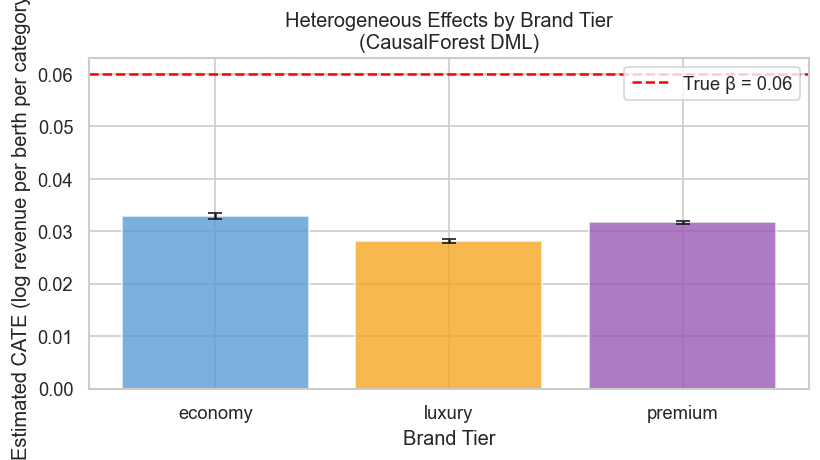

In [5]:
cates = est.effect(X)
p_treated = p_treated.copy()
p_treated["cate"] = cates

tier_cates = p_treated.groupby("brand_tier")["cate"].agg(["mean", "std", "count"]).round(4)
print("CATE by brand tier:")
print(tier_cates)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(tier_cates.index, tier_cates["mean"], 
       yerr=tier_cates["std"] / np.sqrt(tier_cates["count"]),
       capsize=4, color=["#5C9BD6", "#F5A623", "#9B59B6"], alpha=0.8)
ax.axhline(0.06, color="red", ls="--", lw=1.5, label="True β = 0.06")
ax.set_xlabel("Brand Tier")
ax.set_ylabel("Estimated CATE (log revenue per berth per category)")
ax.set_title("Heterogeneous Effects by Brand Tier\n(CausalForest DML)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_cate_by_tier.png", bbox_inches="tight")
plt.show()

## CATE distribution

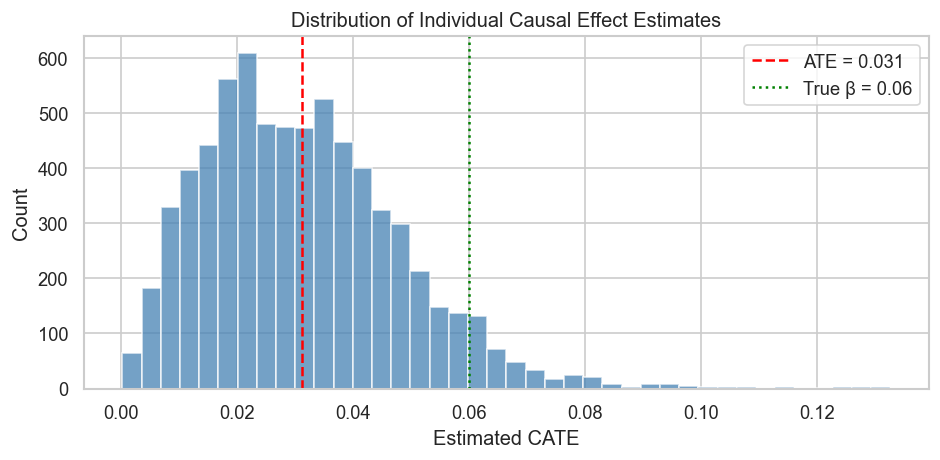

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cates, bins=40, color="steelblue", alpha=0.75, edgecolor="white")
ax.axvline(ate, color="red", ls="--", lw=1.5, label=f"ATE = {ate:.3f}")
ax.axvline(0.06, color="green", ls=":", lw=1.5, label="True β = 0.06")
ax.set_xlabel("Estimated CATE")
ax.set_ylabel("Count")
ax.set_title("Distribution of Individual Causal Effect Estimates")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_cate_distribution.png", bbox_inches="tight")
plt.show()

## Caveats

- DML here uses a simplified panel structure (within-ship demeaning); a proper panel DML would account for temporal autocorrelation.
- CATE estimates at the individual ship level have high variance — the tier-level averages are more reliable.
- Simulated DGP has a *homogeneous* true β = 0.06, so genuine effect heterogeneity by tier is zero by construction. Any heterogeneity found here is estimation noise.